In [86]:
from sklearn.datasets import make_moons, make_classification
import numpy as np
import matplotlib.pyplot as plt
import mglearn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Gradient descent

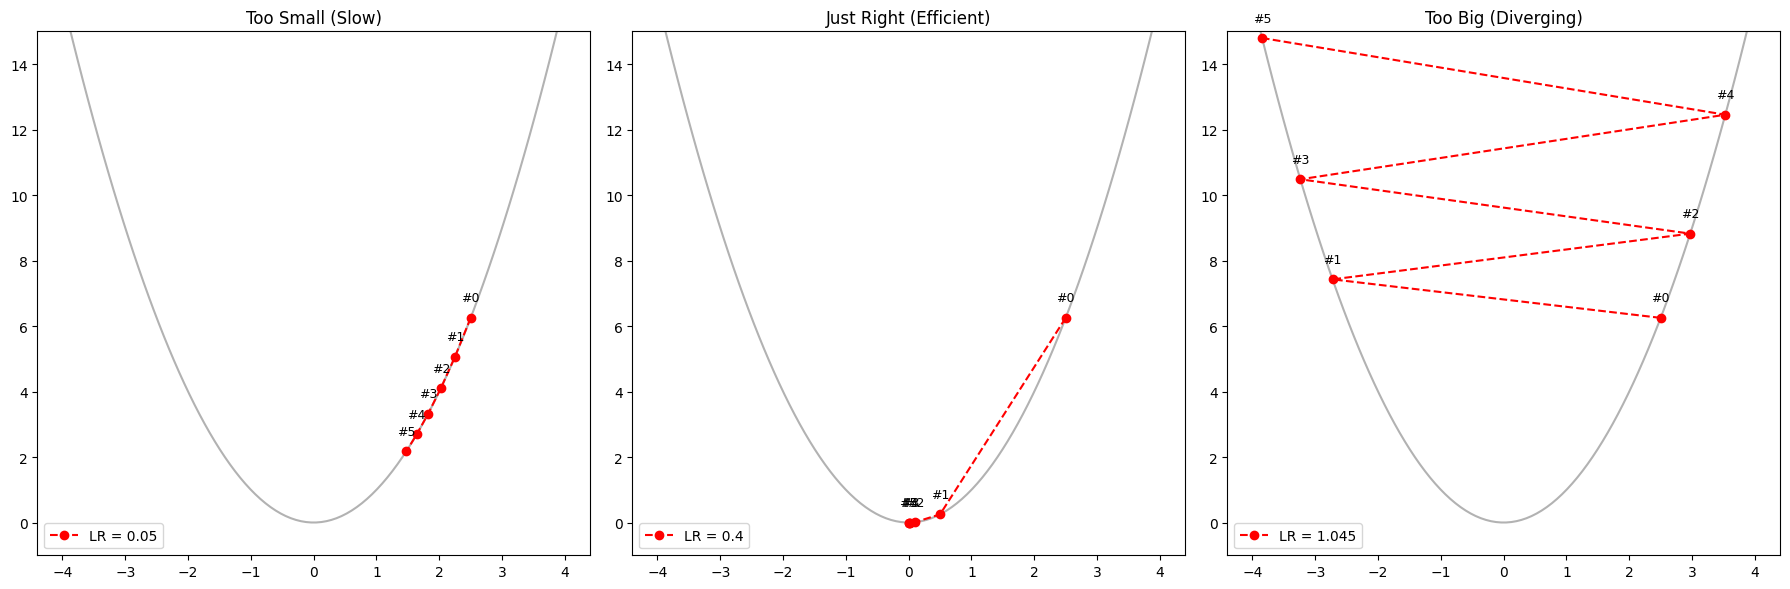

In [87]:
# 1. Setup the function f(x) = x^2 and its derivative f'(x) = 2x
def f(x): return x**2
def df(x): return 2*x

def run_gd(start_x, lr, steps=5):
    points = [start_x]
    x = start_x
    for _ in range(steps):
        x = x - lr * df(x)
        points.append(x)
    return np.array(points)

# 2. Parameters
start_point = 2.5
iterations = 5
# Learning rates:
# 0.05 is tiny, 0.4 is efficient, 1.1 causes divergence (overshooting)
lrs = [0.05, 0.4, 1.045]
titles = ['Too Small (Slow)', 'Just Right (Efficient)', 'Too Big (Diverging)']

# 3. Plotting
x_range = np.linspace(-4, 4, 100)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.tight_layout(rect=[0, 0, 1, 0.95])

for i, lr in enumerate(lrs):
    history = run_gd(start_point, lr, iterations)

    # Plot the parabola
    axes[i].plot(x_range, f(x_range), color='black', alpha=0.3)

    # Plot the descent path
    axes[i].plot(history, f(history), 'o--', color='red', label=f'LR = {lr}')

    # Annotate the iteration numbers
    for j, pt in enumerate(history):
        axes[i].text(pt, f(pt) + 0.5, f'#{j}', fontsize=9, ha='center')

    axes[i].set_title(titles[i])
    axes[i].set_ylim(-1, 15)
    axes[i].legend()

plt.tight_layout()
plt.show()

# Logistic regression

## Linearly separable data

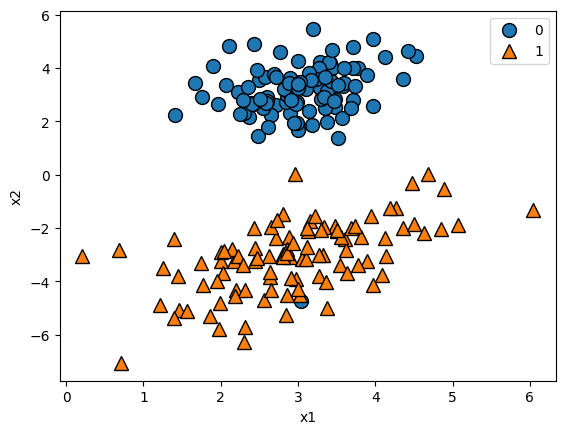

In [88]:
X, y = make_classification(n_samples=200,
                           n_features=2,
                           n_redundant=0,
                           n_clusters_per_class=1,
                           class_sep=3.0,    # larger -> more separable
                           random_state=1)
mglearn.discrete_scatter(X[:,0],X[:,1], y)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()

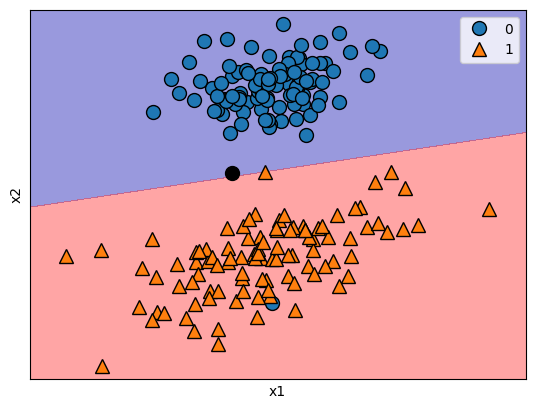

In [89]:
log_reg = LogisticRegression()
log_reg.fit(X,y)
mglearn.discrete_scatter(X[:,0],X[:,1], y)
mglearn.plots.plot_2d_separator(log_reg, X, fill=True, eps=0.5, alpha=.4)
plt.xlabel('x1')
plt.ylabel('x2')
plt.plot(2.5,0,'ko',markersize=10)
plt.legend()

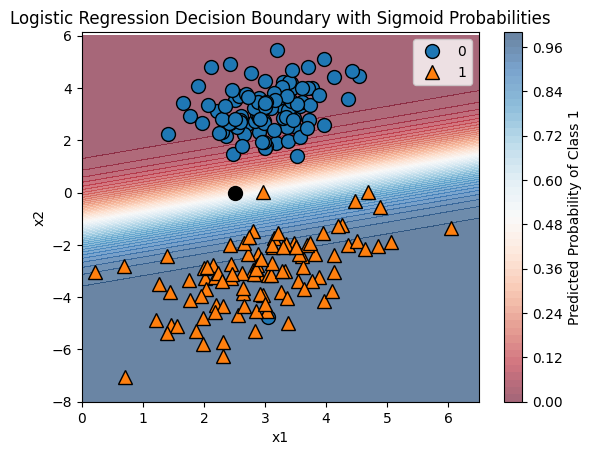

In [90]:
# plot the sigmoid function with the decision boundary of the logistic regression
x1_range = np.linspace(0, 6.5, 100)
x2_range = np.linspace(-8, 6, 100)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
grid_points = np.c_[x1_grid.ravel(), x2_grid.ravel()]
probs = log_reg.predict_proba(grid_points)[:, 1].reshape(x1_grid.shape)
plt.contourf(x1_grid, x2_grid, probs, levels=50, cmap='RdBu', alpha=0.6)
mglearn.discrete_scatter(X[:,0],X[:,1], y)
plt.xlabel('x1')
plt.ylabel('x2')
plt.plot(2.5,0,'ko',markersize=10)
plt.title('Logistic Regression Decision Boundary with Sigmoid Probabilities')
plt.legend()
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()

## Noisy data

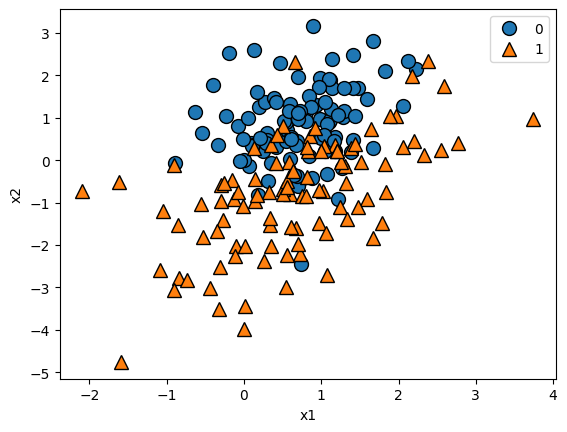

In [91]:
X, y = make_classification(n_samples=200,
                           n_features=2,
                           n_redundant=0,
                           n_clusters_per_class=1,
                           class_sep=0.7,    # larger -> more separable
                           random_state=1)
mglearn.discrete_scatter(X[:,0],X[:,1], y)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()

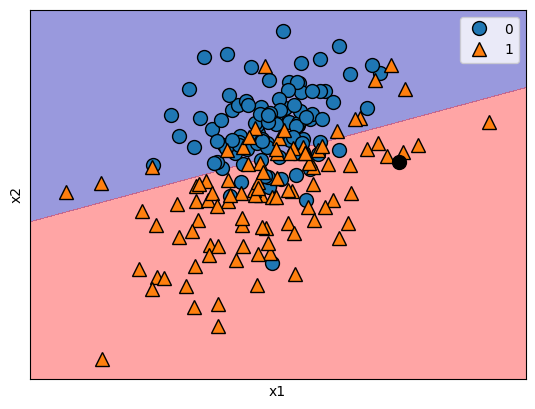

In [92]:
log_reg = LogisticRegression()
log_reg.fit(X,y)
mglearn.discrete_scatter(X[:,0],X[:,1], y)
mglearn.plots.plot_2d_separator(log_reg, X, fill=True, eps=0.5, alpha=.4)
plt.xlabel('x1')
plt.ylabel('x2')
plt.plot(2.5,0,'ko',markersize=10)
plt.legend()

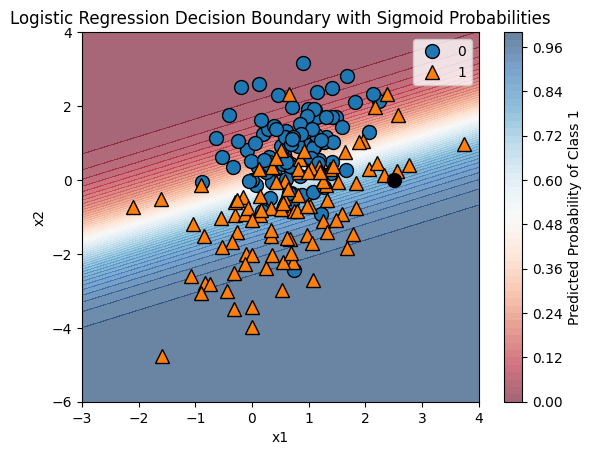

In [93]:
# plot the sigmoid function with the decision boundary of the logistic regression
x1_range = np.linspace(-3, 4, 100)
x2_range = np.linspace(-6, 4, 100)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
grid_points = np.c_[x1_grid.ravel(), x2_grid.ravel()]
probs = log_reg.predict_proba(grid_points)[:, 1].reshape(x1_grid.shape)
plt.contourf(x1_grid, x2_grid, probs, levels=50, cmap='RdBu', alpha=0.6)
mglearn.discrete_scatter(X[:,0],X[:,1], y)
plt.xlabel('x1')
plt.ylabel('x2')
plt.plot(2.5,0,'ko',markersize=10)
plt.title('Logistic Regression Decision Boundary with Sigmoid Probabilities')
plt.legend()
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()

In [94]:
# print the coefficients of the logistic regression model
print("Logistic Regression Coefficients:")
print(f"w1 (x1 weight): {log_reg.coef_[0][0]:.3f}")
print(f"w2 (x2 weight): {log_reg.coef_[0][1]:.3f}")
print(f"Intercept (bias): {log_reg.intercept_[0]:.3f}")

Logistic Regression Coefficients:
w1 (x1 weight): 0.786
w2 (x2 weight): -1.658
Intercept (bias): -0.372


## Linearly non-separable data

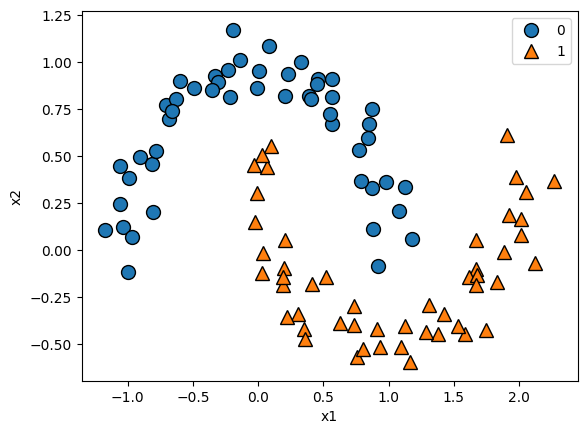

In [95]:
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)
mglearn.discrete_scatter(X[:,0],X[:,1], y)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()

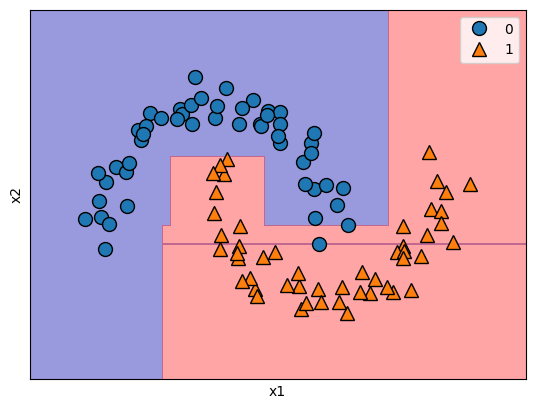

In [96]:
tree = DecisionTreeClassifier(max_depth=6)
tree.fit(X,y)
mglearn.discrete_scatter(X[:,0],X[:,1], y)
mglearn.plots.plot_2d_separator(tree, X, fill=True, eps=0.5, alpha=.4)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()

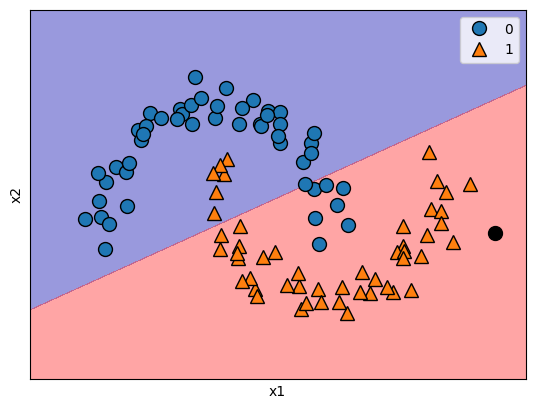

In [97]:
log_reg = LogisticRegression()
log_reg.fit(X,y)
mglearn.discrete_scatter(X[:,0],X[:,1], y)
mglearn.plots.plot_2d_separator(log_reg, X, fill=True, eps=0.5, alpha=.4)
plt.xlabel('x1')
plt.ylabel('x2')
plt.plot(2.5,0,'ko',markersize=10)
plt.legend()

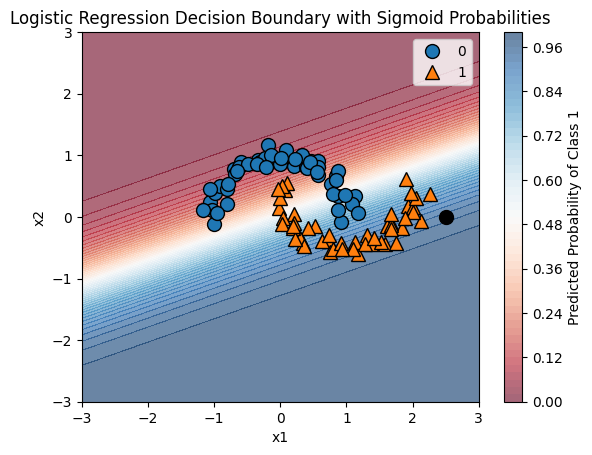

In [98]:
# plot the sigmoid function with the decision boundary of the logistic regression
x1_range = np.linspace(-3, 3, 100)
x2_range = np.linspace(-3, 3, 100)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
grid_points = np.c_[x1_grid.ravel(), x2_grid.ravel()]
probs = log_reg.predict_proba(grid_points)[:, 1].reshape(x1_grid.shape)
plt.contourf(x1_grid, x2_grid, probs, levels=50, cmap='RdBu', alpha=0.6)
mglearn.discrete_scatter(X[:,0],X[:,1], y)
plt.xlabel('x1')
plt.ylabel('x2')
plt.plot(2.5,0,'ko',markersize=10)
plt.title('Logistic Regression Decision Boundary with Sigmoid Probabilities')
plt.legend()
plt.colorbar(label='Predicted Probability of Class 1')
plt.show()

## Sigmoid function

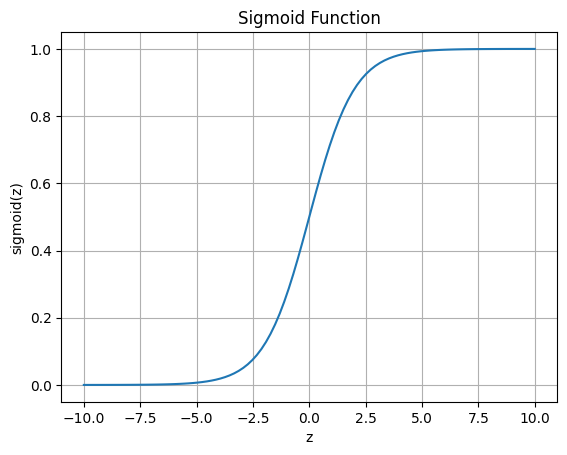

In [99]:
# The sigmoid function is defined as: sigmoid(z) = 1 / (1 + exp(-z))
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
# Plotting the sigmoid function
z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z))
plt.title('Sigmoid Function')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.grid()
plt.show()